# Practical 6: Taming Overfitting — Regularization Techniques
## Deep Learning Lab | BTech Semester 4
## KARTIK KUMAR NDU202400012
### Objective
Apply and evaluate regularization strategies on a dataset prone to overfitting.
Observe how each technique closes the gap between training and validation accuracy.

### What You Will Learn
- What overfitting is and how to detect it from loss/accuracy curves
- Dropout: randomly disabling neurons during training
- L2 Regularization (Weight Decay): penalizing large weights
- Batch Normalization: normalizing layer activations
- Early Stopping: stopping training before overfitting occurs

### References
- Srivastava et al. (2014) — Dropout: A Simple Way to Prevent Neural Networks from Overfitting
  (https://jmlr.org/papers/v15/srivastava14a.html)
- Ioffe & Szegedy (2015) — Batch Normalization (https://arxiv.org/abs/1502.03167)
- Goodfellow et al. — Deep Learning Ch. 7 (Regularization)
- CIFAR-10 dataset: https://www.cs.toronto.edu/~kriz/cifar.html

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)  # fixing seed for reproducibility
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


## Step 2: Load CIFAR-10 (Small Subset to Induce Overfitting)

CIFAR-10: 60,000 color images (32x32x3) across 10 classes.
Using a small subset intentionally creates an overfitting scenario — the network memorizes training data.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 155s 1us/step
Training subset: (3000, 32, 32, 3) samples
Test set: (10000, 32, 32, 3) samples
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


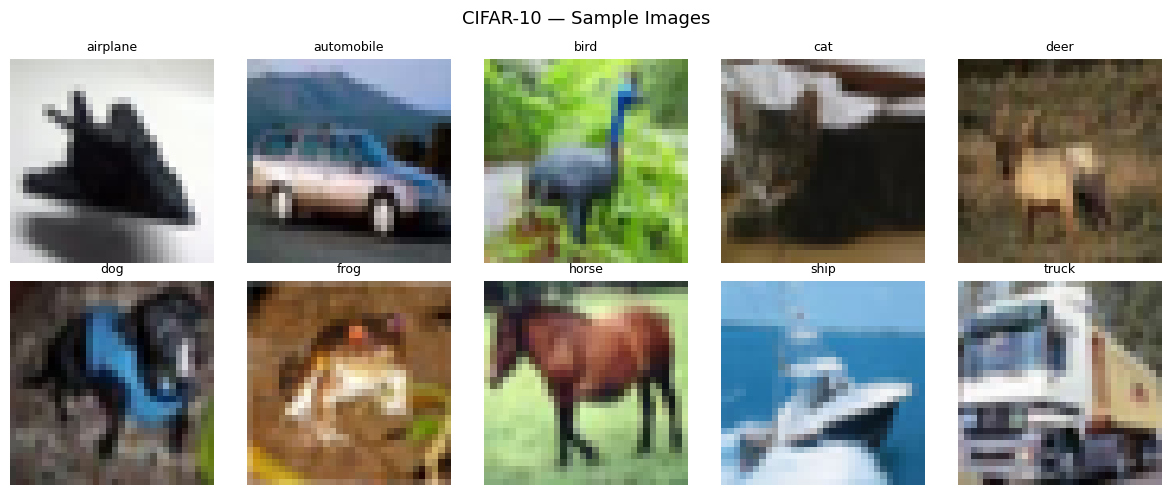

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# scaling pixel values from [0,255] to [0,1] so training is more stable
X_train_full = X_train_full.astype('float32') / 255.0
X_test        = X_test.astype('float32')       / 255.0

# using only 3000 samples on purpose — with less data a big model will memorize instead of learn (overfitting)
SUBSET_SIZE = 3000
X_train = X_train_full[:SUBSET_SIZE]
y_train = y_train_full[:SUBSET_SIZE]

print(f'Training subset: {X_train.shape} samples')
print(f'Test set: {X_test.shape} samples')
print(f'Classes: {class_names}')

# showing one sample image for each of the 10 CIFAR classes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train_full.flatten() == i)[0][0]
    ax.imshow(X_train_full[idx])
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 — Sample Images', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Build Four Model Variants

We train the SAME base architecture with progressive regularization added:

| Iteration | Regularization Applied |
|-----------|------------------------|
| Iter 1 | No regularization (baseline) — will overfit |
| Iter 2 | + Dropout layers |
| Iter 3 | + L2 Regularization + Batch Normalization |
| Iter 4 | + Early Stopping (applied during training) |

All models use the same learning rate and architecture for fair comparison.

In [3]:
def build_baseline():
    """no regularization at all — this model will overfit badly on our small dataset"""
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dense(256, activation='relu', name='dense2'),
        layers.Dense(128, activation='relu', name='dense3'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='Baseline_NoRegularization')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_with_dropout():
    """adding dropout after each hidden layer
    dropout randomly turns off some neurons during training, so the network can't rely on any single neuron too much
    this forces it to learn more general patterns instead of memorizing"""
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4, name='drop1'),  # randomly turning off 40% of neurons each training step
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4, name='drop2'),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3, name='drop3'),
        layers.Dense(10, activation='softmax')
    ], name='Dropout_Regularization')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_with_l2_and_bn():
    """adding L2 regularization + Batch Normalization on top of dropout
    L2 adds a penalty for large weights to the loss — keeps weights small and prevents overfitting
    BatchNorm normalizes activations to mean=0 std=1 after each layer — stabilizes and speeds up training"""
    L2 = 0.001  # how strong the L2 penalty is — higher means weights are pushed smaller more aggressively
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),  # normalizing activations so each layer gets inputs with stable distribution
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='L2_BatchNorm_Dropout')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_with_all():
    """same as Iter 3 but with Early Stopping added during training
    Early Stopping monitors validation loss and stops training when it stops improving
    it's a callback, not a layer — so the architecture looks the same"""
    L2 = 0.001
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='All_Regularization_EarlyStopping')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


print('All model builders defined!')
print('Model summaries will print during training.')

All model builders defined!
Model summaries will print during training.


## Step 4: Train All Four Iterations

In [4]:
EPOCHS = 60
BATCH_SIZE = 64
VAL_SPLIT = 0.2

# Early stopping callback — monitors validation loss
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,                # if val_loss doesn't improve for 8 straight epochs, stop training
    restore_best_weights=True  # go back to the weights that had the best val_loss, not the last ones
)

# storing each model's training history and results for comparison later
all_histories = {}

model_configs = [
    ('Iter 1: No Regularization',          build_baseline,          None,        'red'),
    ('Iter 2: Dropout',                    build_with_dropout,      None,        'blue'),
    ('Iter 3: L2 + BatchNorm + Dropout',   build_with_l2_and_bn,    None,        'orange'),
    ('Iter 4: All + Early Stopping',       build_with_all,          early_stop,  'green'),
]

for name, builder, callback, color in model_configs:
    print(f'\n{"="*55}')
    print(f'Training: {name}')
    print('='*55)
    tf.random.set_seed(42)
    model = builder()
    callbacks = [callback] if callback else []  # only add early stopping for iter 4
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        callbacks=callbacks,
        verbose=0
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    all_histories[name] = {
        'history': history, 'color': color,
        'test_acc': test_acc, 'model': model,
        'epochs_trained': len(history.history['loss'])
    }
    train_acc = history.history['accuracy'][-1]
    val_acc   = history.history['val_accuracy'][-1]
    print(f'  Epochs trained:   {len(history.history["loss"])}')
    print(f'  Train Accuracy:   {train_acc*100:.2f}%')
    print(f'  Val Accuracy:     {val_acc*100:.2f}%')
    print(f'  Test Accuracy:    {test_acc*100:.2f}%')
    print(f'  Overfit gap:      {(train_acc - val_acc)*100:.2f}% (how much better on train vs val — bigger gap = more overfit)')

print('\nAll iterations complete!')


Training: Iter 1: No Regularization
  Epochs trained:   60
  Train Accuracy:   75.33%
  Val Accuracy:     33.50%
  Test Accuracy:    33.73%
  Overfit gap:      41.83% (Train - Val)

Training: Iter 2: Dropout
  Epochs trained:   60
  Train Accuracy:   32.25%
  Val Accuracy:     32.17%
  Test Accuracy:    31.51%
  Overfit gap:      0.08% (Train - Val)

Training: Iter 3: L2 + BatchNorm + Dropout
  Epochs trained:   60
  Train Accuracy:   44.00%
  Val Accuracy:     26.33%
  Test Accuracy:    26.50%
  Overfit gap:      17.67% (Train - Val)

Training: Iter 4: All + Early Stopping
  Epochs trained:   42
  Train Accuracy:   43.42%
  Val Accuracy:     25.83%
  Test Accuracy:    29.50%
  Overfit gap:      17.58% (Train - Val)

All iterations complete!


## Step 5: Visualize Training vs Validation Accuracy — Detecting Overfitting

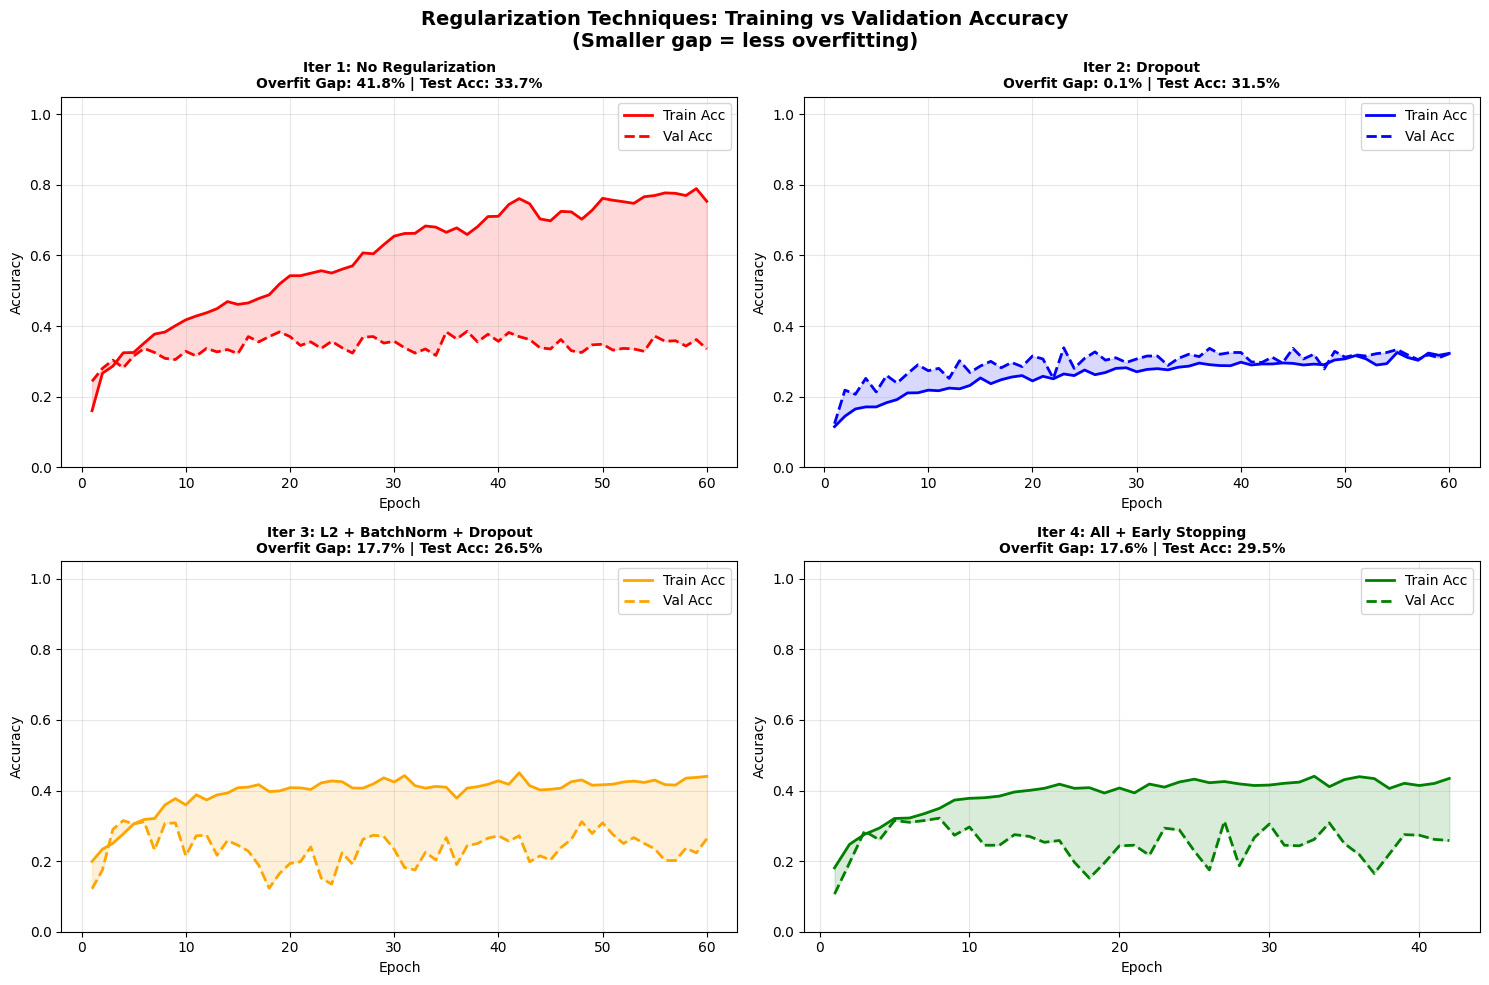

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, (name, res) in zip(axes.flatten(), all_histories.items()):
    h = res['history'].history
    epochs = range(1, len(h['loss'])+1)
    ax.plot(epochs, h['accuracy'], color=res['color'], linewidth=2, label='Train Acc')
    ax.plot(epochs, h['val_accuracy'], color=res['color'], linestyle='--', linewidth=2, label='Val Acc')
    gap = (h['accuracy'][-1] - h['val_accuracy'][-1]) * 100
    ax.set_title(f'{name}\nOverfit Gap: {gap:.1f}% | Test Acc: {res["test_acc"]*100:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    # shading the area between train and val curves to visually show the overfitting gap
    ax.fill_between(epochs, h['accuracy'], h['val_accuracy'],
                    alpha=0.15, color=res['color'], label='Overfit Region')

plt.suptitle('Regularization Techniques: Training vs Validation Accuracy\n(Smaller gap = less overfitting)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Loss Curves — All Models on Same Plot

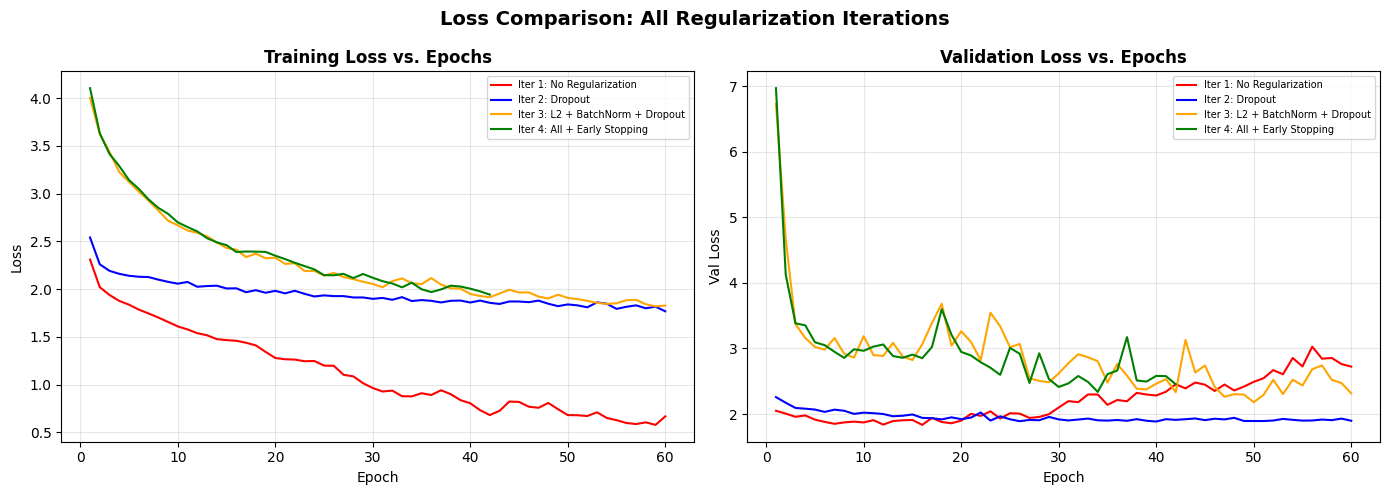

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in all_histories.items():
    h = res['history'].history
    epochs = range(1, len(h['loss'])+1)
    axes[0].plot(epochs, h['loss'], color=res['color'], linewidth=1.5, label=name)
    axes[1].plot(epochs, h['val_loss'], color=res['color'], linewidth=1.5, label=name)

axes[0].set_title('Training Loss vs. Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss vs. Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss Comparison: All Regularization Iterations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Final Comparison Summary Table

In [7]:
rows = []
for name, res in all_histories.items():
    h = res['history'].history
    train_acc = h['accuracy'][-1]
    val_acc   = h['val_accuracy'][-1]
    rows.append({
        'Model': name,
        'Epochs': res['epochs_trained'],
        'Train Acc': f'{train_acc*100:.1f}%',
        'Val Acc': f'{val_acc*100:.1f}%',
        'Test Acc': f'{res["test_acc"]*100:.1f}%',
        'Overfit Gap': f'{(train_acc - val_acc)*100:.1f}%'
    })
df = pd.DataFrame(rows)
print('Regularization Comparison Summary:')
print(df.to_string(index=False))

print('\nKey Takeaways:')
print('  Iter 1 has the biggest gap between train and val → that is severe overfitting')
print('  Dropout (Iter 2) reduces the gap by stopping neurons from relying on each other')
print('  L2 + BatchNorm (Iter 3) stabilizes training further and keeps weights from growing too large')
print('  Early Stopping (Iter 4) quits before the model starts overfitting — also saves training time')

Regularization Comparison Summary:
                           Model  Epochs Train Acc Val Acc Test Acc Overfit Gap
       Iter 1: No Regularization      60     75.3%   33.5%    33.7%       41.8%
                 Iter 2: Dropout      60     32.2%   32.2%    31.5%        0.1%
Iter 3: L2 + BatchNorm + Dropout      60     44.0%   26.3%    26.5%       17.7%
    Iter 4: All + Early Stopping      42     43.4%   25.8%    29.5%       17.6%

Key Takeaways:
  Iter 1 shows the largest Train-Val gap → severe overfitting
  Dropout (Iter 2) reduces gap by preventing co-adaptation of neurons
  L2 + BatchNorm (Iter 3) further stabilizes training and reduces weight magnitude
  Early Stopping (Iter 4) stops before validation loss increases — saves compute too


## Step 8: Illustrate Bias-Variance Tradeoff

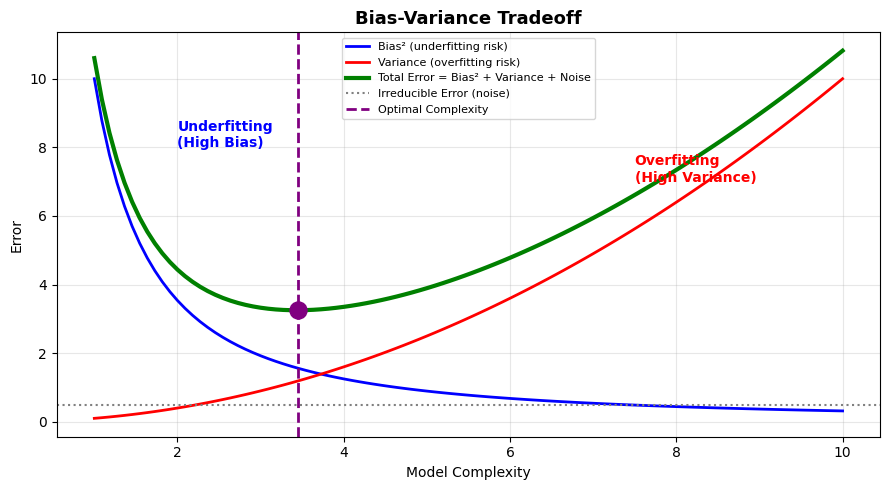

Regularization shifts the model toward the optimal point by reducing variance.


In [8]:
# Conceptual visualization of the Bias-Variance Tradeoff
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # fixing seed for reproducibility
model_complexity = np.linspace(1, 10, 100)

bias_squared = 10 / model_complexity**1.5  # bias goes down as model gets more complex
variance = 0.1 * model_complexity**2  # variance goes up as model gets more complex
total_error = bias_squared + variance + 0.5  # total error = bias² + variance + irreducible noise

plt.figure(figsize=(9, 5))
plt.plot(model_complexity, bias_squared, 'b-', linewidth=2, label='Bias² (underfitting risk)')
plt.plot(model_complexity, variance, 'r-', linewidth=2, label='Variance (overfitting risk)')
plt.plot(model_complexity, total_error, 'g-', linewidth=3, label='Total Error = Bias² + Variance + Noise')
plt.axhline(0.5, color='gray', linestyle=':', label='Irreducible Error (noise)')

opt_idx = np.argmin(total_error)  # finding where total error is minimum — that's the sweet spot
plt.axvline(model_complexity[opt_idx], color='purple', linestyle='--', linewidth=2, label='Optimal Complexity')
plt.scatter([model_complexity[opt_idx]], [total_error[opt_idx]], s=150, color='purple', zorder=5)

plt.annotate('Underfitting\n(High Bias)', xy=(2, 8), fontsize=10, color='blue', fontweight='bold')
plt.annotate('Overfitting\n(High Variance)', xy=(7.5, 7), fontsize=10, color='red', fontweight='bold')

plt.title('Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
plt.xlabel('Model Complexity')
plt.ylabel('Error')
plt.legend(loc='upper center', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('regularization pulls the model toward the sweet spot by reducing variance without increasing bias too much')

---
## Summary

| Technique | Mechanism | Effect |
|-----------|----------|--------|
| **No Regularization** | None | High overfit — large Train-Val gap |
| **Dropout** | Randomly zero out neurons | Prevents co-adaptation, forces redundancy |
| **L2 Regularization** | Penalize large weights in loss | Smaller weights → simpler model |
| **Batch Normalization** | Normalize activations per batch | Stable training, acts as mild regularizer |
| **Early Stopping** | Stop when val_loss stops improving | Prevents over-training, saves compute |

---
## Viva / Self-Check Questions

1. Define overfitting. How do you detect overfitting from training curves? Sketch an example.
2. What is the Bias-Variance Tradeoff? Describe both underfitting and overfitting in these terms.
3. How does Dropout work during training? Does it behave the same way during inference (prediction)? Why?
4. What is L2 Regularization (Weight Decay)? Write the modified loss function formula.
5. What is Batch Normalization? What problem was it designed to solve (hint: look up Internal Covariate Shift)?
6. How does Early Stopping work? What is the patience parameter?
7. Why did we intentionally use a small subset of CIFAR-10? What would happen with the full 50,000 samples?
8. In Iter 1, training accuracy was much higher than validation accuracy. What does this tell you about what the model learned?